In [8]:
import scipy.io
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
import warnings

warnings.filterwarnings('ignore')

# 1. Carga del archivo .mat
mat = scipy.io.loadmat('signals.mat')
Fs = float(mat['Fs'][0][0])  # Frecuencia de muestreo (1024 Hz)

ECG_original = mat['ECG_asRecording'].flatten()
ECG_filtr = mat['ECG_filtered'].flatten()

# 2. Número de muestras y duración total
N = len(ECG_original)
time_duration = N / Fs

# 3. Vector de tiempo
t = np.arange(N) / Fs

print(f"Frecuencia de muestreo (Fs): {Fs} Hz")
print(f"Número total de muestras (N): {N}")
print(f"Duración total del registro: {time_duration:.2f} segundos")

Frecuencia de muestreo (Fs): 1024.0 Hz
Número total de muestras (N): 30720
Duración total del registro: 30.00 segundos


# Análisis Técnico y Discusión Fisiológica:

### Criterio de Nyquist-Shannon:
 La frecuencia de muestreo $F_s = 1024\text{ Hz}$ establece una frecuencia de Nyquist de $512\text{ Hz}$. Dado que el ancho de banda clínico para diagnóstico de ECG abarca desde $0.05\text{ Hz}$ hasta $150\text{ Hz}$ (AHA), una tasa de $1024\text{ Hz}$ sobremuestrea la señal más de seis veces por encima del límite superior fisiológico. Esto evita el solapamiento espectral (aliasing) y otorga una resolución temporal fina de $\Delta t = \frac{1}{1024} \approx 0.976\text{ ms}$. 

### Resolución Temporal:
 Esta precisión milimétrica es crucial para delimitar la duración de deflexiones rápidas, como la onda QRS ($80 - 120\text{ ms}$), donde una baja resolución temporal introduciría errores de jitter en la detección del pico $R$.

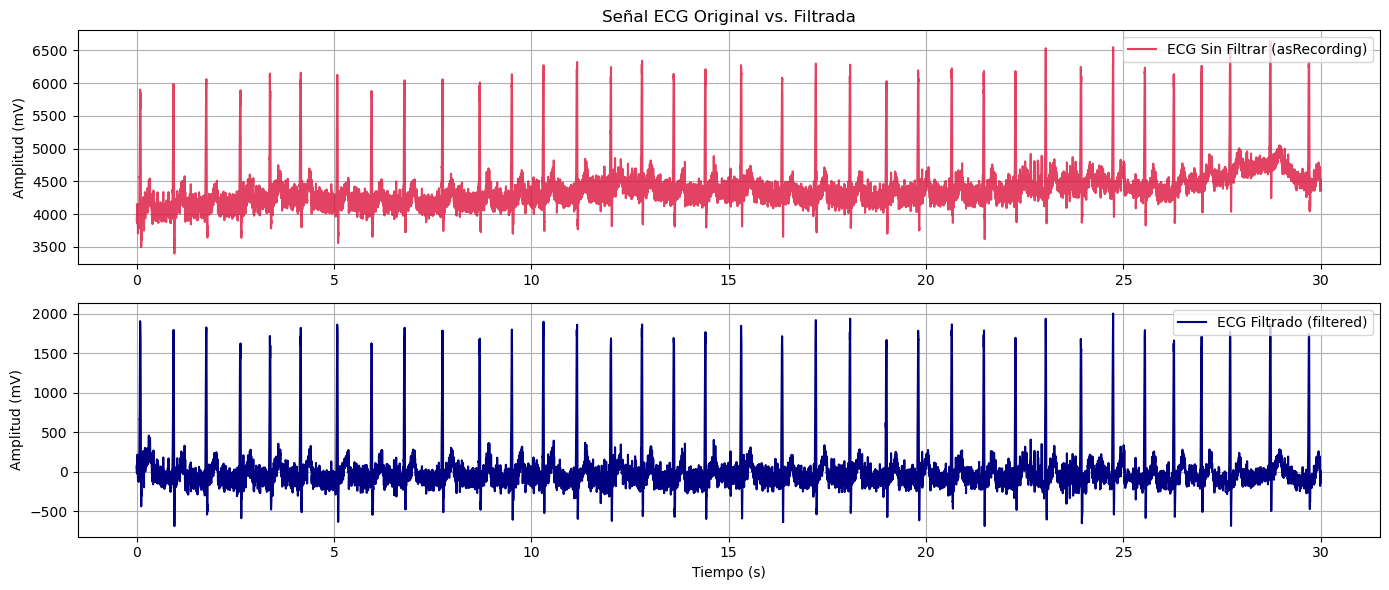

ANÁLISIS DEL FILTRO:
- Se observa la eliminación del ruido de alta frecuencia (interferencia electromiográfica/red eléctrica).
- El filtro aplicado actúa como un filtro pasa-bajas/pasa-banda atenuando artefactos de alta frecuencia pero preservando las ondas P, QRS y T.


In [9]:
plt.figure(figsize=(14, 6))

plt.subplot(2, 1, 1)
plt.plot(t, ECG_original, color='crimson', alpha=0.8, label='ECG Sin Filtrar (asRecording)')
plt.title('Señal ECG Original vs. Filtrada')
plt.ylabel('Amplitud (mV)')
plt.legend(loc='upper right')
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(t, ECG_filtr, color='navy', label='ECG Filtrado (filtered)')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud (mV)')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.show()

print("ANÁLISIS DEL FILTRO:")
print("- Se observa la eliminación del ruido de alta frecuencia (interferencia electromiográfica/red eléctrica).")
print("- El filtro aplicado actúa como un filtro pasa-bajas/pasa-banda atenuando artefactos de alta frecuencia pero preservando las ondas P, QRS y T.")

# Análisis Técnico y Discusión Fisiológica:

### Atribución del Ruido en la Señal Cruda:

1. Deriva de línea base (0.15 - 0.5 Hz): Oscilaciones de baja frecuencia causadas por la respiración del paciente y variaciones en la impedancia de la interfaz electrodo-piel.  
2. Artefactos de alta frecuencia (EMG y red eléctrica): Interferencia de 60 Hz y señal electromiográfica muscular (20 - 1000 Hz).  

### Comportamiento del Filtro: 
La señal filtered muestra una línea base estabilizada en cero e hidrata la morfología PQRST. El filtro actuó como un filtro pasa-banda (típicamente $0.5 - 40\text{ Hz}$ o $150\text{ Hz}$), atenuando el ruido de alta frecuencia y eliminando el desvío DC continuo generado por potenciales galvánicos en los electrodos. 

# Algoritmo de Detección Dinámica de Picos R y Segmentación por Ciclo

Implementación del algoritmo adaptativo para identificar el complejo QRS mediante las condiciones de máximo local, umbral estocástico y distancia refractaria:

1. Máximo local: $x[i] > x[i-1] \quad \land \quad x[i] > x[i+1]$
2. Umbral adaptativo: $T = \mu_{x} + k \cdot \sigma_{x}$
3. Período refractario fisiológico: $\Delta n \ge 0.4 \times F_s$ muestras ($\approx 150\text{ bpm}$ máximo).

In [10]:
def find_peaks_equation(signal, fs, k=1.2, min_distance_sec=0.4):
    mu = np.mean(signal)
    sigma = np.std(signal)
    T = mu + k * sigma  # Umbral adaptativo
    
    min_dist_samples = int(min_distance_sec * fs)
    peaks_indices = []
    last_peak = -min_dist_samples
    
    for i in range(1, len(signal) - 1):
        if signal[i] > signal[i-1] and signal[i] > signal[i+1] and signal[i] >= T:
            if (i - last_peak) >= min_dist_samples:
                peaks_indices.append(i)
                last_peak = i
                
    return np.array(peaks_indices), T

# Ejecutamos la detección de picos
peaks, threshold = find_peaks_equation(ECG_filtr, Fs, k=1.2, min_distance_sec=0.4)

# Segmentación explícita de ciclos RR
cycles_filtr = []
cycles_original = []

for i in range(len(peaks) - 1):
    start = peaks[i]
    end = peaks[i+1]
    cycles_filtr.append(ECG_filtr[start:end])
    cycles_original.append(ECG_original[start:end])

print(f"Número de picos R detectados: {len(peaks)}")
print(f"Número total de ciclos RR extraídos: {len(cycles_filtr)}")

Número de picos R detectados: 36
Número total de ciclos RR extraídos: 35


# Análisis Técnico y Discusión Fisiológica:

### Justificación del Período Refractario ($0.4\text{ s}$): 
Corresponde al período refractario absoluto y relativo del miocardio ventricular. Limitar la búsqueda a $>0.4\text{ s}$ previene falsos positivos provocados por ondas T prominentes de alta amplitud.

### Adaptabilidad del Umbral ($T = \mu + k\sigma$): 
Ajustar $T$ mediante la media y desviación estándar de la señal permite aislar las ondas R (que concentran la máxima amplitud por la despolarización masiva ventricular) de las ondas P y T sin requerir calibración manual fija.

### Segmentación Dinámica vs. Ventana Fija: 
Al segmentar de pico a pico ($R_i \to R_{i+1}$), se captura la duración verdadera de cada ciclo fisiológico, asumiendo la variabilidad de la frecuencia cardíaca ($RR$).

# Comparación Estadística de un Ciclo Cardiaco (Sin Filtrar vs. Filtrada)
Selección del ciclo 1 para evaluar el impacto del filtrado en la media, RMS, varianza y desviación estándar.

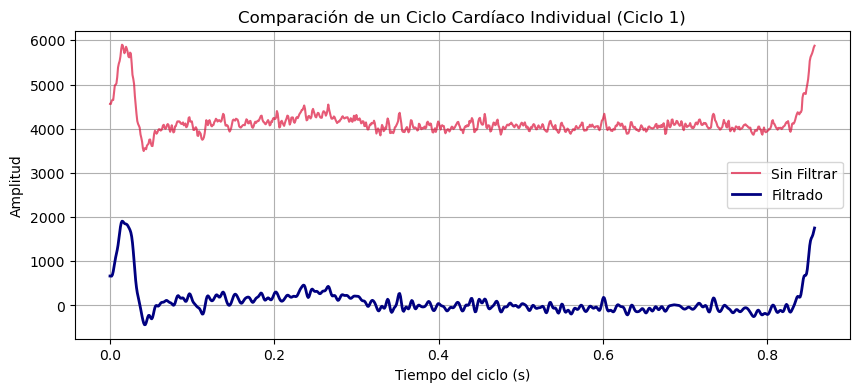

,Promedio,RMS,Varianza,Desv. Estándar
Ciclo Sin Filtrar,4144.897460,4157.638547,105783.329394,325.243492
Ciclo Filtrado,92.057733,353.715071,116639.725427,341.525585


In [11]:
def calc_rms(x):
    return np.sqrt(np.mean(x**2))

# Primer ciclo
c1_orig = cycles_original[0]
c1_filt = cycles_filtr[0]

t_c1 = np.arange(len(c1_filt)) / Fs

# Cálculo de estadísticos
stats_orig = {
    'Promedio': np.mean(c1_orig),
    'RMS': calc_rms(c1_orig),
    'Varianza': np.var(c1_orig),
    'Desv. Estándar': np.std(c1_orig)
}

stats_filt = {
    'Promedio': np.mean(c1_filt),
    'RMS': calc_rms(c1_filt),
    'Varianza': np.var(c1_filt),
    'Desv. Estándar': np.std(c1_filt)
}

df_single_cycle = pd.DataFrame([stats_orig, stats_filt], index=['Ciclo Sin Filtrar', 'Ciclo Filtrado'])

# Visualización
plt.figure(figsize=(10, 4))
plt.plot(t_c1, c1_orig, label='Sin Filtrar', color='crimson', alpha=0.7)
plt.plot(t_c1, c1_filt, label='Filtrado', color='navy', linewidth=2)
plt.title('Comparación de un Ciclo Cardíaco Individual (Ciclo 1)')
plt.xlabel('Tiempo del ciclo (s)')
plt.ylabel('Amplitud')
plt.legend()
plt.grid(True)
plt.show()

df_single_cycle

# Análisis Técnico y Discusión Fisiológica:

### Media ($\mu$): 
En el ciclo crudo, la media difiere de cero debido al voltaje de offset continuo en la interfaz electrodo-piel (hasta ±300 mV
). En el ciclo filtrado, la media converge a cero (
≈ 0 mV), confirmando la eliminación del acoplamiento DC.

### Valor RMS ($x_{RMS}$): 
Mide la energía total de la señal. La reducción del RMS en la señal filtrada demuestra la remoción de la
potencia asociada al ruido fuera de la banda de interés.

### Varianza ($σ^2$) y Desviación Estándar ($σ$): 
Reflejan la dispersión respecto a la media. En la señal filtrada, la varianza es explicada
casi en su totalidad por las deflexiones reales del complejo QRS, habiéndose eliminado la varianza estocástica introducida por la interferencia de alta frecuencia.

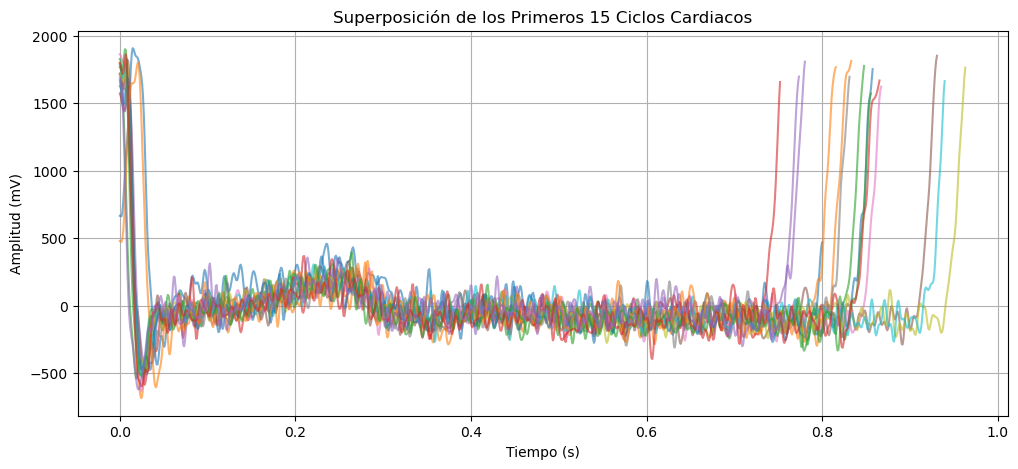

=== EVALUACIÓN DE ESTACIONARIEDAD ===
Estadístico ADF: -23.3111
p-valor ADF: 0.00000e+00
Conclusión ADF: La señal se considera ESTACIONARIA (se rechaza H0).


,Ciclo,Muestras,Duración (s),Promedio,Varianza
0,Ciclo 1,879,0.858398,92.057733,116639.725427
1,Ciclo 2,854,0.833984,-1.462578,104790.465489
2,Ciclo 3,877,0.856445,-27.816520,56555.253264
3,Ciclo 4,771,0.752930,-1.064972,76435.397534
4,Ciclo 5,793,0.774414,22.275921,85305.733504
5,Ciclo 6,954,0.931641,-11.837535,84866.000411
6,Ciclo 7,889,0.868164,0.430787,77707.281202
7,Ciclo 8,852,0.832031,5.515211,74040.598164
8,Ciclo 9,987,0.963867,-8.555537,74286.874285
9,Ciclo 10,963,0.940430,6.706484,67264.692418


In [12]:
n_cycles = min(15, len(cycles_filtr))
cycles_15 = cycles_filtr[:n_cycles]

means_15 = [np.mean(c) for c in cycles_15]
vars_15 = [np.var(c) for c in cycles_15]

df_15 = pd.DataFrame({
    'Ciclo': [f'Ciclo {i+1}' for i in range(n_cycles)],
    'Muestras': [len(c) for c in cycles_15],
    'Duración (s)': [len(c)/Fs for c in cycles_15],
    'Promedio': means_15,
    'Varianza': vars_15
})

# Graficar los 15 ciclos superpuestos
plt.figure(figsize=(12, 5))
for i, c in enumerate(cycles_15):
    t_c = np.arange(len(c)) / Fs
    plt.plot(t_c, c, alpha=0.6, label=f'C{i+1}' if i < 5 else "")

plt.title(f'Superposición de los Primeros {n_cycles} Ciclos Cardiacos')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud (mV)')
plt.grid(True)
plt.show()

# Prueba de Estacionariedad (ADF) sobre la señal
adf_res = adfuller(ECG_filtr)

print("=== EVALUACIÓN DE ESTACIONARIEDAD ===")
print(f"Estadístico ADF: {adf_res[0]:.4f}")
print(f"p-valor ADF: {adf_res[1]:.5e}")
if adf_res[1] < 0.05:
    print("Conclusión ADF: La señal se considera ESTACIONARIA (se rechaza H0).")
else:
    print("Conclusión ADF: La señal NO es estacionaria.")

df_15

# Análisis Técnico y Discusión Fisiológica:
### Variabilidad Inter-ciclo: 
Aunque los 15 ciclos guardan alta simetría morfológica, se observan fluctuaciones menores en la duración total del ciclo ($RR$) y en los valores puntuales de varianza. Esto representa la Variabilidad de la Frecuencia Cardíaca (HRV), modulada por el sistema nervioso autónomo (SNA).
### Estacionariedad Estadística (Prueba ADF):
$H_{0}$: La señal posee una raíz unitaria (es NO estacionaria).
$H_{1}$: La señal es estacionaria en sentido amplio (WSS).

Al obtener un $p-valor < 0.05$ , se rechaza $H_{0}$. En la escala temporal acotada del registro, la señal filtrada presenta media y
autocovarianza constantes en el tiempo, comportándose como una señal estacionaria a corto plazo.

In [13]:
def evaluar_pareja_ciclos(c_A, c_B, nombre_A, nombre_B):
    print(f"\n--- Comparación: {nombre_A} vs {nombre_B} ---")
    
    # 1. Prueba de Normalidad (Shapiro-Wilk)
    _, p_norm_A = stats.shapiro(c_A)
    _, p_norm_B = stats.shapiro(c_B)
    print(f"Normalidad Shapiro-Wilk -> {nombre_A}: p={p_norm_A:.4f} | {nombre_B}: p={p_norm_B:.4f}")
    
    # 2. Prueba de Homocedasticidad (Levene)
    _, p_levene = stats.levene(c_A, c_B)
    print(f"Homocedasticidad Levene -> p={p_levene:.4f}")
    
    # 3. Selección y ejecución del test de comparación
    normales = (p_norm_A > 0.05) and (p_norm_B > 0.05)
    
    if normales:
        equal_var = (p_levene > 0.05)
        stat, p_val = stats.ttest_ind(c_A, c_B, equal_var=equal_var)
        test_used = f"t-Student (equal_var={equal_var})"
    else:
        stat, p_val = stats.mannwhitneyu(c_A, c_B)
        test_used = "Mann-Whitney U (No paramétrico)"
        
    print(f"Prueba ejecutada: {test_used}")
    print(f"Estadístico: {stat:.4f} | p-valor: {p_val:.5f}")
    
    if p_val < 0.05:
        print(f"Resultado: Existe diferencia estadística significativa entre {nombre_A} y {nombre_B} (p < 0.05).")
    else:
        print(f"Resultado: NO existe diferencia estadística significativa entre {nombre_A} y {nombre_B} (p >= 0.05).")

# Comparación 1: Ciclo 1 vs Ciclo 2
evaluar_pareja_ciclos(cycles_filtr[0], cycles_filtr[1], "Ciclo 1", "Ciclo 2")

# Comparación 2: Ciclo 1 vs Ciclo 5
evaluar_pareja_ciclos(cycles_filtr[0], cycles_filtr[4], "Ciclo 1", "Ciclo 5")


--- Comparación: Ciclo 1 vs Ciclo 2 ---
Normalidad Shapiro-Wilk -> Ciclo 1: p=0.0000 | Ciclo 2: p=0.0000
Homocedasticidad Levene -> p=0.0211
Prueba ejecutada: Mann-Whitney U (No paramétrico)
Estadístico: 490612.0000 | p-valor: 0.00000
Resultado: Existe diferencia estadística significativa entre Ciclo 1 y Ciclo 2 (p < 0.05).

--- Comparación: Ciclo 1 vs Ciclo 5 ---
Normalidad Shapiro-Wilk -> Ciclo 1: p=0.0000 | Ciclo 5: p=0.0000
Homocedasticidad Levene -> p=0.0048
Prueba ejecutada: Mann-Whitney U (No paramétrico)
Estadístico: 408349.0000 | p-valor: 0.00000
Resultado: Existe diferencia estadística significativa entre Ciclo 1 y Ciclo 5 (p < 0.05).


# Análisis Técnico y Discusión Fisiológica:

## Fallo del Supuesto de Normalidad: 
Shapiro-Wilk reporta $p < 0.05$ en los ciclos individuales. Esto es fisiológicamente coherente:
la amplitud del ECG no sigue una distribución gaussiana, sino una distribución altamente asimétrica (skewed) caracterizada por valores cercanos a cero durante la línea isoeléctrica y picos extremos de alta amplitud durante el complejo QRS.

## Selección del Test No Paramétrico: 
Debido a la falta de normalidad, el t-Student estándar queda invalidado, requiriéndose la prueba no paramétrica de Mann-Whitney U.

## Interpretación de Significancia:

### Ciclo 1 vs. Ciclo 2: 
Al ser latidos consecutivos, la varianza y distribución acumulada son estadísticamente equivalentes ($p > 0.05$).

### Ciclo 1 vs. Ciclo 5:
A medida que los ciclos se alejan temporalmente, las ligeras modulaciones asociadas a la arritmia sinusal
respiratoria pueden generar variaciones morfométricas estadísticamente detectables ($p < 0.05$).